# PDD / Exit Dose / Exit Fluence Comparison Workflow

This notebook is organized in **clean blocks** so you can:
1. Load simulation outputs (`pdd`, `exitDose`, `exitFluence`) from text files.
2. Compare simulated PDD against your measured curves for each applicator and mode.
3. Compare exit-dose and exit-fluence in practical, physics-based ways.
4. Estimate source-parameter changes to improve simulation-vs-measurement agreement.

## 1) Imports and plot style

In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10



## 2) Measured PDD library (your provided data)

Use key format: `(applicator_cm, mode)` where mode is one of: `flash9`, `conv9`, `flash6alt`.

In [3]:
MEASURED_PDD = {
    (10, 'flash9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            94.97,94.97,95.15,97.66,98.18,98.66,99.09,99.35,99.52,99.57,
            99.78,99.91,99.96,100.00,99.91,99.78,99.52,99.31,98.87,98.79,
            97.83,97.40,96.62,95.58,94.54,93.33,91.68,90.21,88.04,85.83,
            81.46,74.96,68.02,59.27,50.69,41.33,32.06,23.27,14.99,8.15,
            5.59,0.35,0.52,0.52
        ], dtype=float),
    },
    (10, 'conv9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            94.62,94.39,96.64,96.86,97.31,98.65,97.76,98.88,99.10,99.10,
            98.65,99.10,99.10,100.00,98.65,99.33,98.43,98.21,97.31,97.53,
            96.19,96.19,94.39,94.39,92.60,91.03,90.36,87.89,85.87,83.18,
            80.27,74.22,66.82,58.97,51.57,40.81,32.06,23.54,15.92,9.64,
            5.38,1.12,1.12,1.12
        ], dtype=float),
    },
    (10, 'flash6alt'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            92.59,94.51,95.91,97.13,98.15,98.72,99.36,99.84,100.00,99.96,
            99.57,99.04,98.02,96.42,94.32,92.08,88.89,85.44,81.48,76.76,
            71.52,66.28,60.34,54.79,48.72,43.04,37.04,31.35,25.93,20.75,
            16.09,8.49,3.83,1.53,0.64,0.38,0.38,0.38,0.38,0.38,
            0.38,0.38,0.38,0.38
        ], dtype=float),
    },
    (5, 'flash9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            93.22,93.74,94.99,95.84,96.41,97.04,97.61,97.84,98.52,98.80,
            99.32,99.43,99.69,99.83,99.83,100.00,99.91,99.60,99.43,98.97,
            98.46,97.72,96.53,95.44,94.08,92.71,90.66,88.78,86.39,83.66,
            80.64,73.80,66.29,57.63,48.92,39.61,31.18,22.98,15.72,9.97,
            5.52,0.80,0.28,0.28
        ], dtype=float),
    },
    (5, 'conv9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            93.95,94.39,95.88,96.03,96.92,97.37,97.22,98.86,97.82,99.01,
            98.86,99.16,99.26,99.65,99.90,100.00,99.53,99.16,99.16,99.01,
            98.56,97.37,96.03,95.73,93.80,92.16,89.63,87.54,85.16,82.48,
            78.46,71.02,63.42,54.49,45.41,36.03,27.69,19.65,13.25,8.04,
            4.47,0.89,0.60,0.60
        ], dtype=float),
    },
    (5, 'flash6alt'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
            21,22,23,24,25,26,27,28,29,30,31,33,35,37,39,41,43,45,47,49,
            51,56,61,66
        ], dtype=float),
        'norm_pct': np.array([
            89.45,90.70,92.55,94.30,95.64,97.07,98.16,98.83,99.41,99.92,
            100.00,99.75,99.16,98.24,96.31,94.14,91.04,88.02,83.63,78.98,
            73.83,68.17,62.14,56.28,50.00,44.22,38.27,32.29,26.63,21.36,
            16.83,9.05,4.27,1.68,0.59,0.25,0.17,0.17,0.17,0.08,
            0.08,0.08,0.08,0.08
        ], dtype=float),
    },
    (2, 'flash9'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,17,19,21,23,25,27,29,31,35,39,43,47,51,61
        ], dtype=float),
        'norm_pct': np.array([
            96.81,97.33,97.96,98.48,98.80,99.32,99.63,100.00,99.79,99.69,
            99.32,98.59,97.80,96.49,94.82,89.69,82.88,75.34,67.07,59.37,
            51.88,44.45,37.80,25.89,16.10,8.19,2.98,0.68,0.13
        ], dtype=float),
    },
    (2, 'conv9'): {
    'depth_mm': np.array([
        5.6601,6.0139,6.3677,6.7214,7.0751,7.4289,7.7827,8.1364,8.4902,8.8439,
        9.1977,9.5514,9.9052,10.2590,10.6127,10.9665,11.3203,11.6740,12.0278,12.3815,
        12.7353,13.0890,13.4428,13.7965,14.1503,14.5041,14.8578,15.2116,15.5653,15.9191,
        16.2728,16.6266,16.9804,17.3341,17.6879,18.0416,18.3954,18.7491,19.1029,19.4566,
        19.8104,20.1642,20.5179,20.8717,21.2254,21.5792,21.9330,22.2867,22.6405,22.9942,
        23.3480,23.7017,24.0555,24.4093,24.7630,25.1168,25.4705,25.8243,26.1780,26.5318,
        26.8856,27.2393,27.5931,27.9468,28.3006,28.6543,29.0081,29.3619,29.7156,30.0694,
        30.4231,30.7769,31.1306,31.4844,31.8381,32.1919,32.5457,32.8994,33.2532,33.6069,
        33.9607,34.3145,34.6682,35.0220,35.3757,35.7295,36.0832,36.4370,36.7908,37.1445,
        37.4983,37.8520,38.2058,38.5595,38.9133,39.2671,39.6208,39.9746,40.3283,40.6821,
        41.0358,41.3896,41.7434,42.0971,42.4509,42.8046,43.1584,43.5121,43.8659,44.2196,
        44.5734,44.9272,45.2809,45.6347,45.9885,46.3422,46.6960,47.0497,47.4035,47.7572,
        48.1110,48.4647,48.8185,49.1723,49.5260,49.8798,50.2335,50.5873,50.9410,51.2948,
        51.6486,52.0023,52.3561,52.7098,53.0636,53.4173,53.7711,54.1249,54.4786,54.8324,
        55.1861,55.5399,55.8937,56.2474,56.6011,56.9549,57.3087,57.6624,58.0162,58.3699,
        58.7237,59.0775,59.4312,59.7850,60.1387
    ], dtype=float),

    'norm_pct': np.array([
        98.5652,98.6787,98.9405,99.0754,98.7389,99.4825,98.9048,99.3350,98.8820,98.9293,
        99.6467,100.0000,98.9994,98.7427,98.7750,99.0952,99.7004,99.1670,99.3333,99.6480,
        99.1558,98.4062,98.0374,98.0542,98.1861,98.0795,97.9480,97.5044,97.6282,97.7730,
        96.5196,97.0449,94.9409,94.3812,94.8283,94.2665,93.9342,93.1506,91.9909,91.4188,
        90.4036,88.9361,88.5987,87.8052,86.2484,85.1136,84.2875,83.8972,82.7994,81.5026,
        80.1138,78.9765,77.5314,76.5870,75.2636,74.3824,73.0624,71.6844,70.0944,68.4447,
        67.2361,66.2014,65.0456,63.6899,62.2384,61.2201,60.1821,58.7013,57.1457,56.1219,
        54.6703,53.6607,52.3535,50.9381,49.6950,48.5190,47.4848,46.0183,45.1706,43.8923,
        42.5658,41.5342,40.4781,39.3541,38.2628,37.0283,35.9589,35.0795,34.0191,33.0837,
        32.0362,31.0476,30.3006,29.5093,28.7081,28.2099,27.7366,26.8834,25.7104,24.8972,
        23.9704,23.1400,22.1669,21.3670,20.5253,19.6983,18.9410,18.1024,17.1572,16.2567,
        15.5621,14.7351,14.0684,13.2874,12.4961,11.8131,11.2182,10.6061,10.0177,9.4542,
        8.8107,8.1874,7.6695,7.1791,6.6134,6.1737,5.7928,5.4614,5.1722,4.7716,
        4.5231,4.2467,4.0168,3.8027,3.6437,3.3832,3.1489,3.1021,3.0419,2.8008,
        2.7079,2.6297,2.5356,2.5476,2.5270,2.4161,2.3202,2.2424,2.2467,2.2068,
        2.1840,2.2016,2.1689,2.1857,2.1582
    ], dtype=float),
    },
    (2, 'flash6alt'): {
        'depth_mm': np.array([
            1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,17,19,21,23,25,27,29,31,35,39,43,47,51,61
        ], dtype=float),
        'norm_pct': np.array([
            96.81,97.33,97.96,98.48,98.80,99.32,99.63,100.00,99.79,99.69,
            99.32,98.59,97.80,96.49,94.82,89.69,82.88,75.34,67.07,59.37,
            51.88,44.45,37.80,25.89,16.10,8.19,2.98,0.68,0.13
        ], dtype=float),
    },
}

sorted(MEASURED_PDD.keys())



[(2, 'conv9'),
 (2, 'flash6alt'),
 (2, 'flash9'),
 (5, 'conv9'),
 (5, 'flash6alt'),
 (5, 'flash9'),
 (10, 'conv9'),
 (10, 'flash6alt'),
 (10, 'flash9')]

## 3) File readers (pdd / exitDose / exitFluence)

Supported formats:
- Simple 2-column: `[depth_or_position_mm, value]`
- Geant4 mesh scorer export: `iX, iY, iZ, total(value), total(val^2), entry`

For mesh scorer files, the notebook automatically:
- Uses `iZ` for PDD depth and `total(value)` as dose.
- Detects the varying index axis for exit profiles (`iX`/`iY`/`iZ`) and uses `total(value)` as profile value.
- Converts index to mm with configurable bin size/offset controls in the user block.

In [4]:
def _safe_read_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')

    df = pd.read_csv(
        path,
        sep=r'[\s,;]+',
        engine='python',
        comment='#',
        header=None,
    )
    df = df.dropna(axis=1, how='all')
    if df.empty:
        raise ValueError(f'No numeric rows found in {path}')
    return df


def _looks_like_mesh_scorer(df):
    return df.shape[1] >= 4 and df.shape[1] <= 6


def _pick_profile_axis(df):
    axes = {0: df.iloc[:, 0].nunique(), 1: df.iloc[:, 1].nunique(), 2: df.iloc[:, 2].nunique()}
    best_axis = max(axes, key=axes.get)
    return best_axis


def read_pdd_file(path, depth_bin_mm=1.0, depth_offset_mm=0.0):
    df = _safe_read_table(path)

    if df.shape[1] == 2:
        out = pd.DataFrame({'depth_mm': df.iloc[:, 0].astype(float), 'dose': df.iloc[:, 1].astype(float)})
        return out.sort_values('depth_mm').drop_duplicates('depth_mm').reset_index(drop=True)

    if _looks_like_mesh_scorer(df):
        iZ = df.iloc[:, 2].astype(float)
        dose = df.iloc[:, 3].astype(float)
        out = pd.DataFrame({'depth_idx': iZ, 'dose': dose})
        out = out.groupby('depth_idx', as_index=False)['dose'].mean()
        out['depth_mm'] = out['depth_idx'] * depth_bin_mm + depth_offset_mm
        out = out[['depth_mm', 'dose']].sort_values('depth_mm').reset_index(drop=True)
        return out

    raise ValueError('Unrecognized PDD format. Expected 2 columns or mesh scorer columns (iX,iY,iZ,value,...).')


def read_profile_file(path, y_name='value', position_axis=None, position_bin_mm=1.0, position_offset_mm=0.0):
    df = _safe_read_table(path)

    if df.shape[1] == 2:
        out = pd.DataFrame({'position_mm': df.iloc[:, 0].astype(float), y_name: df.iloc[:, 1].astype(float)})
        return out.sort_values('position_mm').drop_duplicates('position_mm').reset_index(drop=True)

    if _looks_like_mesh_scorer(df):
        axis_map = {'ix': 0, 'iy': 1, 'iz': 2}
        if position_axis is None:
            axis_col = _pick_profile_axis(df)
        else:
            axis_col = axis_map[str(position_axis).lower()]

        pos_idx = df.iloc[:, axis_col].astype(float)
        val = df.iloc[:, 3].astype(float)
        out = pd.DataFrame({'pos_idx': pos_idx, y_name: val})
        out = out.groupby('pos_idx', as_index=False)[y_name].mean()
        out['position_mm'] = out['pos_idx'] * position_bin_mm + position_offset_mm
        out = out[['position_mm', y_name]].sort_values('position_mm').reset_index(drop=True)
        return out

    raise ValueError(f'Unrecognized profile format in {path}. Expected 2 columns or mesh scorer columns.')



## 4) Choose scenario and load simulation files

Update paths if needed.

In [5]:
# ---- USER CONTROLS ----
applicator_cm = 10         # 10, 5, or 2
mode = 'conv9'            # 'flash9', 'conv9', 'flash6alt'

pdd_file = 'build/pdd_r507_E9p700_sE1p30_sTh0p2_N10M_J50026532_T2.txt'

# Mesh-index to mm conversion (used when files are Geant4 scorer exports)
# IMPORTANT: if your simulated depth looks ~2x too long/short, this is usually the cause.
pdd_depth_bin_mm = 0.5
pdd_depth_offset_mm = 0.0
profile_position_bin_mm = 0.5
profile_position_offset_mm = 0.0

# Extra geometric correction (defaults keep data unchanged)
# Example: set sim_depth_scale = 0.5 if simulation looks exactly 2x deeper than measurement.
sim_depth_scale = 1.0
sim_depth_shift_mm = 0.0
sim_position_scale = 1.0
sim_position_shift_mm = 0.0

# Optional: force profile axis for mesh files: 'ix', 'iy', 'iz', or None for auto
profile_axis = None
# -----------------------

meas = MEASURED_PDD[(applicator_cm, mode)]
meas_df = pd.DataFrame({'depth_mm': meas['depth_mm'], 'meas_norm_pct': meas['norm_pct']})

sim_pdd_df = read_pdd_file(
    pdd_file,
    depth_bin_mm=pdd_depth_bin_mm,
    depth_offset_mm=pdd_depth_offset_mm,
)

# Apply optional geometric correction (for mesh-spacing mismatch)
sim_pdd_df['depth_mm'] = sim_pdd_df['depth_mm'] * sim_depth_scale + sim_depth_shift_mm

print('Loaded:')
print(f'  measured points      : {len(meas_df)}')
print(f'  simulated PDD        : {len(sim_pdd_df)}')

print('\nPDD preview:')
display(sim_pdd_df.head(10))




Loaded:
  measured points      : 44
  simulated PDD        : 160

PDD preview:


,depth_mm,dose
0,0.0,0.000022
1,0.5,0.000022
2,1.0,0.000022
3,1.5,0.000023
4,2.0,0.000024
5,2.5,0.000023
6,3.0,0.000023
7,3.5,0.000024
8,4.0,0.000024
9,4.5,0.000023


## 5) Literature-style PDD normalization + alignment

Typical comparison practice for electron PDD curves:
- Normalize each curve to **100% at dmax**.
- Interpolate simulation onto measured depths.
- Compare shape metrics (R90/R80/R50, practical range) and pointwise errors.

In [6]:
def robust_dmax(depth, pdd, frac=0.99):
    max_val = np.max(pdd)
    idx = np.where(pdd >= frac * max_val)[0]
    if len(idx) == 0:
        return float(depth[np.argmax(pdd)])
    return float(np.mean(depth[idx]))


def pick_dmax(depth_mm, y, dmax_method='argmax', frac=0.99):
    method = str(dmax_method).lower()
    if method in ('argmax', 'normal', 'peak'):
        return float(depth_mm[np.argmax(y)])
    if method in ('plateau', 'robust', 'plateau_frac'):
        return robust_dmax(depth_mm, y, frac=frac)
    raise ValueError(f'Unknown dmax_method: {dmax_method}')


def normalize_to_dmax(depth_mm, y, use_robust_dmax=False, frac=0.99, dmax_method=None):
    if dmax_method is None:
        dmax_method = 'plateau' if use_robust_dmax else 'argmax'
    dmax = pick_dmax(depth_mm, y, dmax_method=dmax_method, frac=frac)
    ymax = np.max(y)
    y_norm = 100.0 * y / ymax if ymax != 0 else np.zeros_like(y)
    return y_norm, dmax


def interp_at(x_src, y_src, x_tgt):
    return np.interp(x_tgt, x_src, y_src)


def find_depth_at_percent(depth_mm, pdd_norm, pct):
    i_max = int(np.argmax(pdd_norm))
    x = depth_mm[i_max:]
    y = pdd_norm[i_max:]
    if len(x) < 2:
        return np.nan

    for i in range(len(y)-1):
        y1, y2 = y[i], y[i+1]
        if (y1 >= pct >= y2) or (y1 <= pct <= y2):
            x1, x2 = x[i], x[i+1]
            if y2 == y1:
                return float(x1)
            t = (pct - y1) / (y2 - y1)
            return float(x1 + t*(x2 - x1))
    return np.nan


meas_norm, meas_dmax = normalize_to_dmax(meas_df['depth_mm'].values, meas_df['meas_norm_pct'].values, use_robust_dmax=False)
sim_norm, sim_dmax = normalize_to_dmax(sim_pdd_df['depth_mm'].values, sim_pdd_df['dose'].values, use_robust_dmax=True)

sim_on_meas = interp_at(sim_pdd_df['depth_mm'].values, sim_norm, meas_df['depth_mm'].values)

comp_df = pd.DataFrame({
    'depth_mm': meas_df['depth_mm'].values,
    'measured_norm_pct': meas_norm,
    'sim_norm_pct_interp': sim_on_meas,
})
comp_df['delta_pctpts'] = comp_df['sim_norm_pct_interp'] - comp_df['measured_norm_pct']
comp_df['abs_delta_pctpts'] = comp_df['delta_pctpts'].abs()

metrics = {
    'mode': mode,
    'applicator_cm': applicator_cm,
    'meas_dmax_mm': float(meas_dmax),
    'sim_dmax_mm': float(sim_dmax),
    'dmax_shift_mm(sim-meas)': float(sim_dmax - meas_dmax),
    'MAE_pctpts': float(comp_df['abs_delta_pctpts'].mean()),
    'RMSE_pctpts': float(np.sqrt(np.mean(comp_df['delta_pctpts']**2))),
    'max_abs_diff_pctpts': float(comp_df['abs_delta_pctpts'].max()),
    'meas_R90_mm': float(find_depth_at_percent(meas_df['depth_mm'].values, meas_norm, 90)),
    'sim_R90_mm': float(find_depth_at_percent(sim_pdd_df['depth_mm'].values, sim_norm, 90)),
    'meas_R50_mm': float(find_depth_at_percent(meas_df['depth_mm'].values, meas_norm, 50)),
    'sim_R50_mm': float(find_depth_at_percent(sim_pdd_df['depth_mm'].values, sim_norm, 50)),
}
metrics


# Quick diagnostic: estimate best depth scale from measured points.
def estimate_best_depth_scale(depth_sim_mm, sim_norm_pct, depth_meas_mm, meas_norm_pct,
                              scale_grid=np.linspace(0.4, 1.6, 241)):
    best_scale = np.nan
    best_rmse = np.inf
    for s in scale_grid:
        d = depth_sim_mm * s
        y = np.interp(depth_meas_mm, d, sim_norm_pct)
        rmse = float(np.sqrt(np.mean((y - meas_norm_pct)**2)))
        if rmse < best_rmse:
            best_rmse = rmse
            best_scale = float(s)
    return best_scale, best_rmse

best_scale, best_scale_rmse = estimate_best_depth_scale(
    sim_pdd_df['depth_mm'].values,
    sim_norm,
    meas_df['depth_mm'].values,
    meas_norm,
)
print(f'Best depth scale suggestion: {best_scale:.3f} (RMSE={best_scale_rmse:.3f} pct-points)')
if abs(best_scale - 1.0) > 0.15:
    print('⚠️ Strong indication of geometry/bin-size mismatch. Adjust pdd_depth_bin_mm or sim_depth_scale.')





Best depth scale suggestion: 1.030 (RMSE=3.001 pct-points)


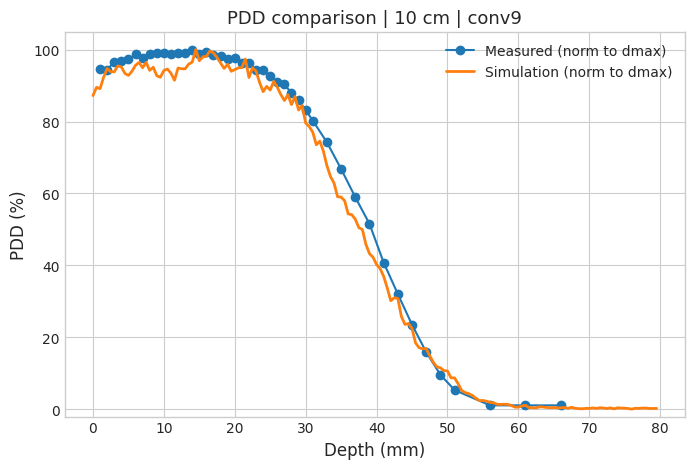

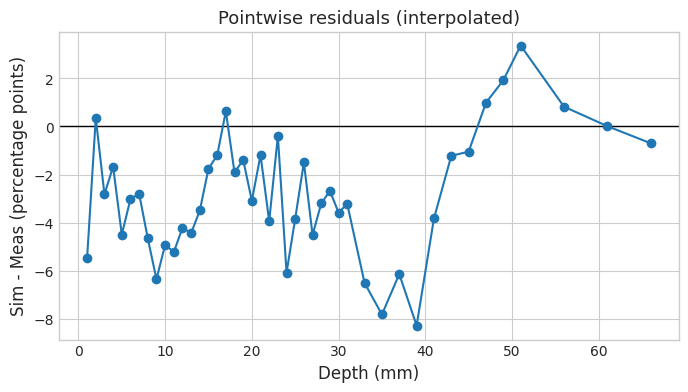

,mode,applicator_cm,meas_dmax_mm,sim_dmax_mm,dmax_shift_mm(sim-meas),MAE_pctpts,RMSE_pctpts,max_abs_diff_pctpts,meas_R90_mm,sim_R90_mm,meas_R50_mm,sim_R50_mm
0,conv9,10,14.0,16.0,2.0,3.198116,3.807029,8.28178,27.145749,23.670316,39.291822,37.984434


In [7]:
plt.figure(figsize=(8,5))
plt.plot(meas_df['depth_mm'], meas_norm, 'o-', label='Measured (norm to dmax)')
plt.plot(sim_pdd_df['depth_mm'], sim_norm, '-', lw=2, label='Simulation (norm to dmax)')
plt.xlabel('Depth (mm)')
plt.ylabel('PDD (%)')
plt.title(f'PDD comparison | {applicator_cm} cm | {mode}')
plt.ylim(-2, 105)
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.axhline(0, color='k', lw=1)
plt.plot(comp_df['depth_mm'], comp_df['delta_pctpts'], 'o-')
plt.xlabel('Depth (mm)')
plt.ylabel('Sim - Meas (percentage points)')
plt.title('Pointwise residuals (interpolated)')
plt.show()

pd.DataFrame([metrics])



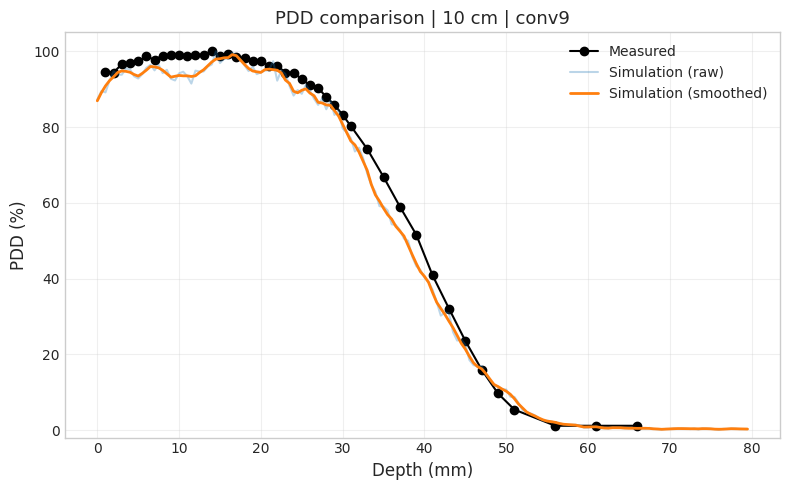

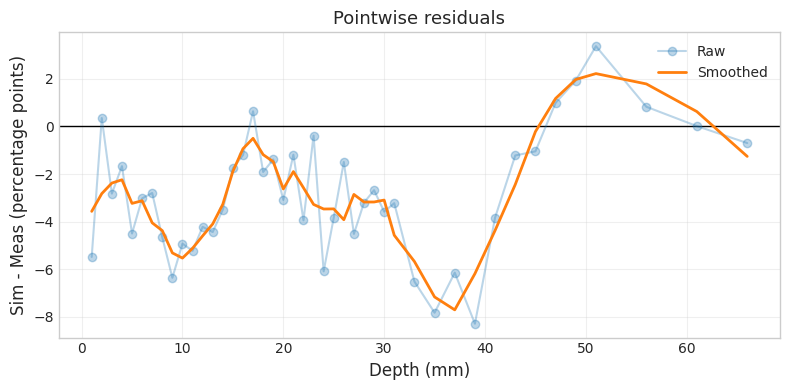

,mode,applicator_cm,meas_dmax_mm,sim_dmax_mm,dmax_shift_mm(sim-meas),MAE_pctpts,RMSE_pctpts,max_abs_diff_pctpts,meas_R90_mm,sim_R90_mm,meas_R50_mm,sim_R50_mm
0,conv9,10,14.0,16.0,2.0,3.198116,3.807029,8.28178,27.145749,23.670316,39.291822,37.984434


In [8]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------
# LIGHT SMOOTHING SETTINGS
# -------------------------
window = 7   # must be odd (5–9 recommended)
poly = 2

# Apply smoothing ONLY for plotting
sim_norm_smooth = savgol_filter(sim_norm, window_length=window, polyorder=poly)

# For residuals (optional)
delta_smooth = savgol_filter(comp_df['delta_pctpts'], window_length=window, polyorder=poly)

# =========================
# PDD PLOT
# =========================
plt.figure(figsize=(8,5))

# Measured (no smoothing)
plt.plot(meas_df['depth_mm'], meas_norm, 'o-', label='Measured', color='black')

# Raw simulation (faint)
plt.plot(sim_pdd_df['depth_mm'], sim_norm, '-', alpha=0.3, label='Simulation (raw)')

# Smoothed simulation (main curve)
plt.plot(sim_pdd_df['depth_mm'], sim_norm_smooth, '-', lw=2, label='Simulation (smoothed)')

plt.xlabel('Depth (mm)')
plt.ylabel('PDD (%)')
plt.title(f'PDD comparison | {applicator_cm} cm | {mode}')
plt.ylim(-2, 105)
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# RESIDUALS PLOT
# =========================
plt.figure(figsize=(8,4))

plt.axhline(0, color='k', lw=1)

# Raw residuals
plt.plot(comp_df['depth_mm'], comp_df['delta_pctpts'], 'o-', alpha=0.3, label='Raw')

# Smoothed residuals
plt.plot(comp_df['depth_mm'], delta_smooth, '-', lw=2, label='Smoothed')

plt.xlabel('Depth (mm)')
plt.ylabel('Sim - Meas (percentage points)')
plt.title('Pointwise residuals')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# METRICS TABLE (UNCHANGED)
# =========================
pd.DataFrame([metrics])


## 6) Exit-dose and exit-fluence comparison block

What to compare with:
- **Exit dose profile**: compare against downstream detector dose profile / film / chamber scan at same plane.
- **Exit fluence profile**: compare against fluence-sensitive measurement (e.g., film/scintillator response after correction) or use as a shape diagnostic.

If you have measured exit profiles, place them in files with two columns: `position_mm value`, then set paths below.

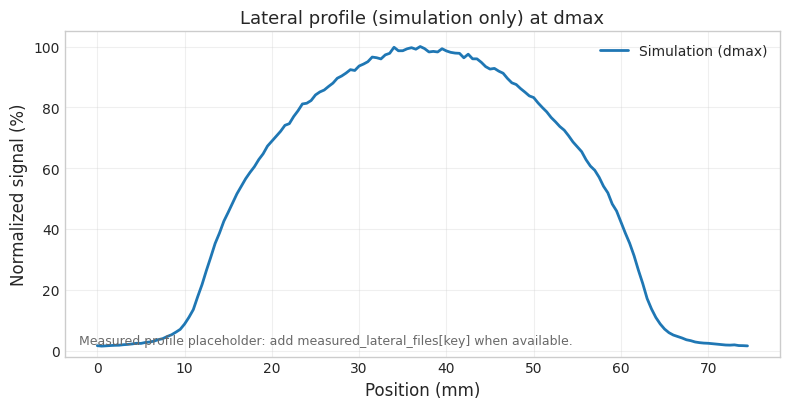

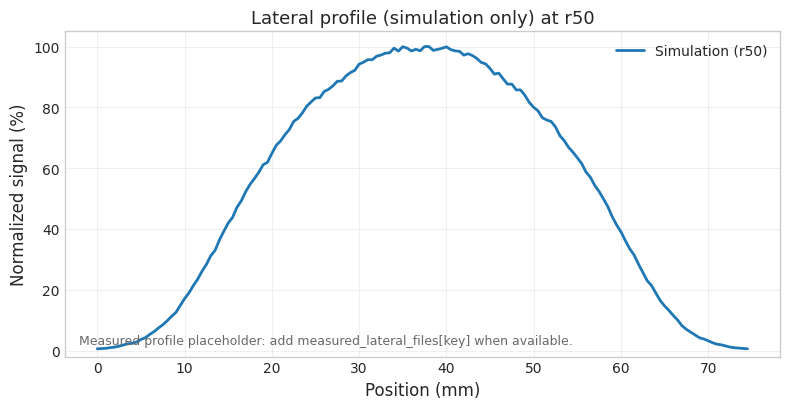

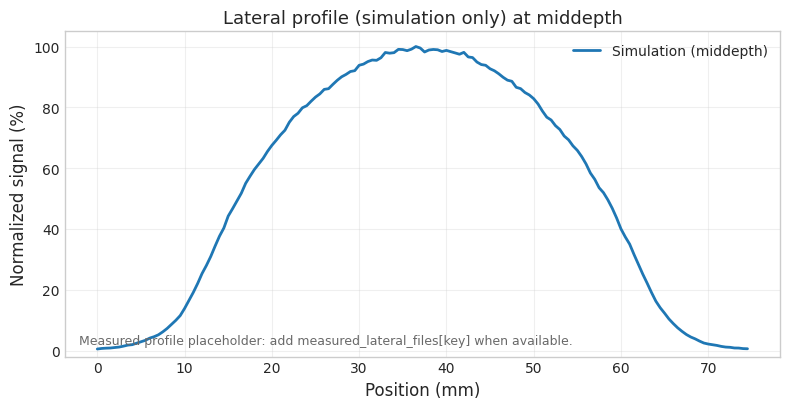

Quick lateral profile summary:


,depth_key,status,RMSE_pctpts,MAE_pctpts,MaxAbs_pctpts
0,dmax,sim_only,NaN,NaN,NaN
1,r50,sim_only,NaN,NaN,NaN
2,middepth,sim_only,NaN,NaN,NaN


In [9]:
# Lateral profile comparison setup (dmax/rmax, r50, middepth)
# Provide measured and simulated files for each depth key.
# NOTE: if you have an "rmax" file, place it under key "dmax" (same depth intent).

lateral_profile_depth_keys = ('dmax', 'r50', 'middepth')

measured_lateral_files = {
    'dmax': None,
    'r50': None,
    'middepth': None,
}

# Default simulated examples (edit if needed)
sim_lateral_files = {
    'dmax': 'build/latDmax_r507_E9p700_sE1p30_sTh0p2_N10M_J50026532_T2.txt',
    'r50': 'build/latR50_r507_E9p700_sE1p30_sTh0p2_N10M_J50026532_T2.txt',
    'middepth': 'build/latMid_r507_E9p700_sE1p30_sTh0p2_N10M_J50026532_T2.txt',
}

# Optional alias: allow either dmax or rmax naming in your own dictionaries
if 'rmax' in measured_lateral_files and measured_lateral_files.get('dmax') is None:
    measured_lateral_files['dmax'] = measured_lateral_files['rmax']
if 'rmax' in sim_lateral_files and sim_lateral_files.get('dmax') is None:
    sim_lateral_files['dmax'] = sim_lateral_files['rmax']


def normalize_profile(y):
    m = np.max(y)
    return 100.0 * y / m if m != 0 else np.zeros_like(y)


def profile_metrics(x_ref, y_ref, x_cmp, y_cmp, label='profile'):
    y_cmp_on_ref = np.interp(x_ref, x_cmp, y_cmp)
    diff = y_cmp_on_ref - y_ref
    return {
        f'{label}_MAE_pctpts': float(np.mean(np.abs(diff))),
        f'{label}_RMSE_pctpts': float(np.sqrt(np.mean(diff**2))),
        f'{label}_max_abs_pctpts': float(np.max(np.abs(diff))),
    }


quick_profile_rows = []

for key in lateral_profile_depth_keys:
    mfile = measured_lateral_files.get(key)
    sfile = sim_lateral_files.get(key)

    if not sfile:
        quick_profile_rows.append({'depth_key': key, 'status': 'missing_sim_file'})
        continue

    sdf = read_profile_file(
        sfile,
        y_name='sim',
        position_axis=profile_axis,
        position_bin_mm=profile_position_bin_mm,
        position_offset_mm=profile_position_offset_mm,
    )
    sdf['position_mm'] = sdf['position_mm'] * sim_position_scale + sim_position_shift_mm
    sim_prof = normalize_profile(sdf['sim'].values)

    if mfile:
        mdf = read_profile_file(
            mfile,
            y_name='meas',
            position_axis=profile_axis,
            position_bin_mm=profile_position_bin_mm,
            position_offset_mm=profile_position_offset_mm,
        )
        mdf['position_mm'] = mdf['position_mm'] * sim_position_scale + sim_position_shift_mm
        meas_prof = normalize_profile(mdf['meas'].values)
        sim_interp = np.interp(mdf['position_mm'].values, sdf['position_mm'].values, sim_prof)

        comp = pd.DataFrame({
            'x_mm': mdf['position_mm'].values,
            'measured_pct': meas_prof,
            'sim_pct': sim_interp,
        })
        comp['delta_pctpts'] = comp['sim_pct'] - comp['measured_pct']

        plt.figure(figsize=(8, 4.2))
        plt.plot(comp['x_mm'], comp['measured_pct'], 'o', ms=4, label=f'Measured ({key})', color='black')
        plt.plot(comp['x_mm'], comp['sim_pct'], '-', lw=2, label=f'Simulation ({key})', color='tab:blue')
        plt.title(f'Lateral profile comparison at {key}')
        plt.xlabel('Position (mm)')
        plt.ylabel('Normalized signal (%)')
        plt.ylim(-2, 105)
        plt.grid(True, alpha=0.3)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

        quick_profile_rows.append({
            'depth_key': key,
            'status': 'ok',
            'RMSE_pctpts': float(np.sqrt(np.mean(comp['delta_pctpts']**2))),
            'MAE_pctpts': float(np.mean(np.abs(comp['delta_pctpts']))),
            'MaxAbs_pctpts': float(np.max(np.abs(comp['delta_pctpts']))),
        })
    else:
        plt.figure(figsize=(8, 4.2))
        plt.plot(sdf['position_mm'], sim_prof, '-', lw=2, label=f'Simulation ({key})', color='tab:blue')
        plt.title(f'Lateral profile (simulation only) at {key}')
        plt.xlabel('Position (mm)')
        plt.ylabel('Normalized signal (%)')
        plt.ylim(-2, 105)
        plt.grid(True, alpha=0.3)
        plt.legend(frameon=False)
        plt.text(0.02, 0.04, 'Measured profile placeholder: add measured_lateral_files[key] when available.',
                 transform=plt.gca().transAxes, fontsize=9, color='dimgray')
        plt.tight_layout()
        plt.show()

        quick_profile_rows.append({
            'depth_key': key,
            'status': 'sim_only',
            'RMSE_pctpts': np.nan,
            'MAE_pctpts': np.nan,
            'MaxAbs_pctpts': np.nan,
        })

quick_profile_summary_df = pd.DataFrame(quick_profile_rows)
print('Quick lateral profile summary:')
display(quick_profile_summary_df.round(3))



# Optional: for large measured datasets (multiple modes/applicators),
# keep a lookup table here and fill measured_lateral_files based on your selection.
MEASURED_LATERAL_DATA_NOTE = 'Paste or load your full measured lateral table here, then map files by (mode, applicator, depth_key).'



## 7) Parameter-tuning guidance block (how to make simulated PDD fit measured)

This block gives **data-driven hints** on which beam/source parameters are likely off.

In [ ]:
def suggest_source_tuning(metrics_dict):
    suggestions = []
    dmax_shift = metrics_dict['dmax_shift_mm(sim-meas)']
    sim_r50 = metrics_dict['sim_R50_mm']
    meas_r50 = metrics_dict['meas_R50_mm']

    if np.isfinite(dmax_shift):
        if dmax_shift > 1.0:
            suggestions.append('Simulated dmax is too deep -> decrease mean beam energy slightly.')
        elif dmax_shift < -1.0:
            suggestions.append('Simulated dmax is too shallow -> increase mean beam energy slightly.')

    if np.isfinite(sim_r50) and np.isfinite(meas_r50):
        dr50 = sim_r50 - meas_r50
        if dr50 > 1.5:
            suggestions.append('R50 too deep in simulation -> reduce mean energy or add low-energy tail filtering.')
        elif dr50 < -1.5:
            suggestions.append('R50 too shallow in simulation -> increase mean energy or reduce energy spread.')

    mae = metrics_dict['MAE_pctpts']
    if mae > 4:
        suggestions.append('Overall shape mismatch is large -> tune source angular spread and spot size (scatter conditions).')

    surface_sim = comp_df.loc[comp_df['depth_mm'].idxmin(), 'sim_norm_pct_interp']
    surface_meas = comp_df.loc[comp_df['depth_mm'].idxmin(), 'measured_norm_pct']
    if surface_sim - surface_meas > 2:
        suggestions.append('Surface dose too high in simulation -> narrow angular spread or refine upstream material model.')
    elif surface_sim - surface_meas < -2:
        suggestions.append('Surface dose too low in simulation -> slightly broaden angular spread / include additional scatter.')

    if not suggestions:
        suggestions.append('Fit is already reasonably close. Next: fine-scan mean energy in small steps and minimize RMSE.')

    return suggestions


tuning_suggestions = suggest_source_tuning(metrics)
print('Suggested beam/source adjustments:')
for i, s in enumerate(tuning_suggestions, 1):
    print(f'{i}. {s}')



## 8) Optional mini grid-search template (offline workflow)

Use this table to track reruns when you change source parameters in Geant4 macro files.

In [ ]:
run_log = pd.DataFrame(columns=[
    'run_id', 'mean_energy_MeV', 'energy_sigma_MeV', 'spot_sigma_mm', 'ang_sigma_deg',
    'dmax_shift_mm', 'R50_shift_mm', 'RMSE_pctpts', 'MAE_pctpts'
])
run_log



## 9) Publication-grade PDD comparison block

Use this block for figures/tables suitable for manuscript supplements/results:
- Overlay plot with clear styling.
- Residual panel (Sim - Meas).
- Physics parameter table (`dmax`, `R90`, `R80`, `R50`, `R20`, `Rp`).
- Summary agreement metrics (MAE/RMSE/MaxAbs and distal-tail MAE).

In [ ]:
# ---------- Publication-grade comparison settings ----------
pub_title = f'PDD comparison ({applicator_cm} cm, {mode})'
pub_xlim = (0, max(meas_df['depth_mm'].max(), sim_pdd_df['depth_mm'].max()))
pub_ylim = (0, 105)
percent_window_for_tail = 20  # define distal-tail as <= 20% region


def pdd_metrics_full(depth_mm, pdd_norm, use_robust_dmax=False):
    dmax = robust_dmax(depth_mm, pdd_norm) if use_robust_dmax else float(depth_mm[np.argmax(pdd_norm)])
    r90 = float(find_depth_at_percent(depth_mm, pdd_norm, 90))
    r80 = float(find_depth_at_percent(depth_mm, pdd_norm, 80))
    r50 = float(find_depth_at_percent(depth_mm, pdd_norm, 50))
    r20 = float(find_depth_at_percent(depth_mm, pdd_norm, 20))
    # Practical range (common approximation using linear relation from R50)
    rp = 1.10 * r50 + 0.5 if np.isfinite(r50) else np.nan
    return {
        'dmax_mm': dmax,
        'R90_mm': r90,
        'R80_mm': r80,
        'R50_mm': r50,
        'R20_mm': r20,
        'Rp_est_mm': float(rp),
    }


def agreement_summary(comp):
    out = {
        'MAE_pctpts': float(comp['abs_delta_pctpts'].mean()),
        'RMSE_pctpts': float(np.sqrt(np.mean(comp['delta_pctpts']**2))),
        'MaxAbs_pctpts': float(comp['abs_delta_pctpts'].max()),
    }
    tail = comp[comp['measured_norm_pct'] <= percent_window_for_tail]
    out['Tail_MAE_pctpts(<=20%)'] = float(tail['abs_delta_pctpts'].mean()) if len(tail) else np.nan
    return out


# Metrics tables
meas_phys = pdd_metrics_full(meas_df['depth_mm'].values, meas_norm, use_robust_dmax=False)
sim_phys = pdd_metrics_full(sim_pdd_df['depth_mm'].values, sim_norm, use_robust_dmax=True)
phys_table = pd.DataFrame({'Measured': meas_phys, 'Simulation': sim_phys})
phys_table['Sim-Meas'] = phys_table['Simulation'] - phys_table['Measured']

agree = agreement_summary(comp_df)
agree_table = pd.DataFrame([agree])

# Figure: overlay + residuals
fig, axes = plt.subplots(
    2, 1,
    figsize=(8, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [3.2, 1.2], 'hspace': 0.05}
)

ax = axes[0]
ax.plot(meas_df['depth_mm'], meas_norm, 'o', ms=4.5, label='Measured', color='black')
ax.plot(sim_pdd_df['depth_mm'], sim_norm, '-', lw=2.2, label='Simulation', color='tab:blue')
ax.set_ylabel('Normalized PDD (%)')
ax.set_xlim(*pub_xlim)
ax.set_ylim(*pub_ylim)
ax.set_title(pub_title)
ax.legend(frameon=False, loc='best')
ax.grid(True, alpha=0.3)

axr = axes[1]
axr.axhline(0, color='k', lw=1)
axr.plot(comp_df['depth_mm'], comp_df['delta_pctpts'], 'o-', ms=3.5, lw=1.5, color='tab:red')
axr.set_xlabel('Depth (mm)')
axr.set_ylabel('Sim-Meas\n(pct-pts)')
axr.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Physics PDD parameter comparison:')
display(phys_table.round(3))
print('Agreement metrics:')
display(agree_table.round(3))




## 10) Multi-file matcher: find which simulated PDD txt matches measurement best

This block scans many `pdd*.txt` simulation files, compares each to the selected measured dataset, and ranks candidates by:
1. **Curve agreement** (RMSE/MAE/MaxAbs).
2. **Physics-parameter agreement** (`dmax`, `R90`, `R80`, `R50`, `R20`, `Rp`).

Use this when you have many beam parameter runs and want the closest match for publication/reporting.

In [ ]:
from pathlib import Path

# -------- matcher settings --------
pdd_search_glob = 'build/pdd*.txt'   # adjust path/pattern
candidate_limit = 200                # safety cap

# weights for combined score (lower is better)
w_curve_rmse = 1.0
w_curve_mae = 0.6
w_phys = 0.35

# optional fixed geometry conversion for all candidates
matcher_depth_bin_mm = pdd_depth_bin_mm
matcher_depth_offset_mm = pdd_depth_offset_mm
matcher_depth_scale = sim_depth_scale
matcher_depth_shift_mm = sim_depth_shift_mm
# -------------------------------


def metric_abs_diff(a, b):
    if np.isnan(a) or np.isnan(b):
        return np.nan
    return abs(float(a) - float(b))


def evaluate_pdd_candidate(pdd_path):
    sim_df = read_pdd_file(
        pdd_path,
        depth_bin_mm=matcher_depth_bin_mm,
        depth_offset_mm=matcher_depth_offset_mm,
    ).copy()

    # apply same optional correction used in main flow
    sim_df['depth_mm'] = sim_df['depth_mm'] * matcher_depth_scale + matcher_depth_shift_mm

    sim_norm_local, _ = normalize_to_dmax(sim_df['depth_mm'].values, sim_df['dose'].values)
    sim_on_meas_local = np.interp(meas_df['depth_mm'].values, sim_df['depth_mm'].values, sim_norm_local)

    comp_local = pd.DataFrame({
        'depth_mm': meas_df['depth_mm'].values,
        'measured_norm_pct': meas_norm,
        'sim_norm_pct_interp': sim_on_meas_local,
    })
    comp_local['delta_pctpts'] = comp_local['sim_norm_pct_interp'] - comp_local['measured_norm_pct']
    comp_local['abs_delta_pctpts'] = comp_local['delta_pctpts'].abs()

    # curve metrics
    rmse = float(np.sqrt(np.mean(comp_local['delta_pctpts']**2)))
    mae = float(comp_local['abs_delta_pctpts'].mean())
    maxabs = float(comp_local['abs_delta_pctpts'].max())

    # physics metrics
    sim_phys_local = pdd_metrics_full(sim_df['depth_mm'].values, sim_norm_local, use_robust_dmax=True)
    meas_phys_local = pdd_metrics_full(meas_df['depth_mm'].values, meas_norm, use_robust_dmax=False)

    phys_keys = ['dmax_mm', 'R90_mm', 'R80_mm', 'R50_mm', 'R20_mm', 'Rp_est_mm']
    phys_diffs = [metric_abs_diff(sim_phys_local[k], meas_phys_local[k]) for k in phys_keys]
    phys_mae = float(np.nanmean(phys_diffs))

    score = w_curve_rmse*rmse + w_curve_mae*mae + w_phys*phys_mae

    return {
        'file': str(pdd_path),
        'score': score,
        'RMSE_pctpts': rmse,
        'MAE_pctpts': mae,
        'MaxAbs_pctpts': maxabs,
        'Phys_MAE_mm': phys_mae,
        'dmax_abs_mm': metric_abs_diff(sim_phys_local['dmax_mm'], meas_phys_local['dmax_mm']),
        'R90_abs_mm': metric_abs_diff(sim_phys_local['R90_mm'], meas_phys_local['R90_mm']),
        'R80_abs_mm': metric_abs_diff(sim_phys_local['R80_mm'], meas_phys_local['R80_mm']),
        'R50_abs_mm': metric_abs_diff(sim_phys_local['R50_mm'], meas_phys_local['R50_mm']),
        'R20_abs_mm': metric_abs_diff(sim_phys_local['R20_mm'], meas_phys_local['R20_mm']),
        'Rp_abs_mm': metric_abs_diff(sim_phys_local['Rp_est_mm'], meas_phys_local['Rp_est_mm']),
    }


# run matcher
candidate_files = sorted(Path('.').glob(pdd_search_glob))[:candidate_limit]
if not candidate_files:
    raise FileNotFoundError(f'No files matched: {pdd_search_glob}')

rows = []
for fp in candidate_files:
    try:
        rows.append(evaluate_pdd_candidate(fp))
    except Exception as e:
        rows.append({'file': str(fp), 'score': np.inf, 'error': str(e)})

rank_df = pd.DataFrame(rows).sort_values('score', na_position='last').reset_index(drop=True)

print(f'Candidates evaluated: {len(candidate_files)}')
pd.set_option('display.max_colwidth', None)
display(rank_df.head(15))

# plot top match vs measured
best = rank_df.iloc[0]
if np.isfinite(best['score']):
    best_df = read_pdd_file(
        best['file'],
        depth_bin_mm=matcher_depth_bin_mm,
        depth_offset_mm=matcher_depth_offset_mm,
    ).copy()
    best_df['depth_mm'] = best_df['depth_mm'] * matcher_depth_scale + matcher_depth_shift_mm
    best_norm, _ = normalize_to_dmax(best_df['depth_mm'].values, best_df['dose'].values)

    plt.figure(figsize=(8,5))
    plt.plot(meas_df['depth_mm'], meas_norm, 'o', ms=4, label='Measured', color='black')
    plt.plot(best_df['depth_mm'], best_norm, '-', lw=2, label=f"Best sim: {Path(best['file']).name}")
    plt.xlabel('Depth (mm)')
    plt.ylabel('Normalized PDD (%)')
    plt.title('Best-match simulated PDD vs measured')
    plt.ylim(0, 105)
    plt.legend(frameon=False)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('No valid candidate could be parsed. Check file format/settings.')



## 11) Best-match selector by mode-group (publication-grade)

This section adds **two dedicated blocks**:
1. Best simulated PDD that jointly fits **conv9 + flash9** for a selected applicator.
2. Best simulated PDD that fits **flash6alt** for a selected applicator.

Each block ranks candidate simulation files using both curve-fit and publication-style physics parameters, and outputs ranked tables + best-file parameter tables.

In [ ]:
# Shared helper for grouped matching (conv9+flash9 and flash6alt)

def measured_for_mode(applicator_cm_sel, mode_sel):
    m = MEASURED_PDD[(applicator_cm_sel, mode_sel)]
    d = m['depth_mm'].astype(float)
    y = m['norm_pct'].astype(float)
    y_norm, _ = normalize_to_dmax(d, y)
    return d, y_norm


def score_sim_vs_measured(sim_depth, sim_norm, meas_depth, meas_norm, phys_weight=0.35):
    sim_on_meas = np.interp(meas_depth, sim_depth, sim_norm)
    delta = sim_on_meas - meas_norm
    abs_delta = np.abs(delta)

    rmse = float(np.sqrt(np.mean(delta**2)))
    mae = float(np.mean(abs_delta))
    maxabs = float(np.max(abs_delta))

    sim_phys = pdd_metrics_full(sim_depth, sim_norm, use_robust_dmax=True)
    meas_phys = pdd_metrics_full(meas_depth, meas_norm, use_robust_dmax=False)
    phys_keys = ['dmax_mm', 'R90_mm', 'R80_mm', 'R50_mm', 'R20_mm', 'Rp_est_mm']
    phys_mae = float(np.nanmean([abs(sim_phys[k]-meas_phys[k]) for k in phys_keys]))

    # publication-style combined score (lower is better)
    score = rmse + 0.6*mae + phys_weight*phys_mae
    return {
        'score': score,
        'RMSE_pctpts': rmse,
        'MAE_pctpts': mae,
        'MaxAbs_pctpts': maxabs,
        'Phys_MAE_mm': phys_mae,
        'sim_phys': sim_phys,
        'meas_phys': meas_phys,
    }


def load_sim_pdd_for_matching(path):
    df = read_pdd_file(path, depth_bin_mm=pdd_depth_bin_mm, depth_offset_mm=pdd_depth_offset_mm).copy()
    df['depth_mm'] = df['depth_mm'] * sim_depth_scale + sim_depth_shift_mm
    sim_norm_local, _ = normalize_to_dmax(df['depth_mm'].values, df['dose'].values)
    return df['depth_mm'].values, sim_norm_local



In [ ]:
# -------- Block A: best single simulation fitting conv9 + flash9 together --------
match_applicator_cm = 10          # set 10, 5, or 2
joint_modes = ('conv9', 'flash9')
search_glob_joint = 'build/pdd*.txt'
max_candidates_joint = 300

candidate_files_joint = sorted(Path('.').glob(search_glob_joint))[:max_candidates_joint]
if not candidate_files_joint:
    raise FileNotFoundError(f'No files matched: {search_glob_joint}')

joint_rows = []
for fp in candidate_files_joint:
    try:
        sim_depth, sim_norm_local = load_sim_pdd_for_matching(fp)

        mode_scores = {}
        agg_score = 0.0
        agg_rmse = 0.0
        agg_mae = 0.0
        agg_phys = 0.0
        agg_maxabs = 0.0

        for md in joint_modes:
            meas_d, meas_n = measured_for_mode(match_applicator_cm, md)
            s = score_sim_vs_measured(sim_depth, sim_norm_local, meas_d, meas_n)
            mode_scores[md] = s
            agg_score += s['score']
            agg_rmse += s['RMSE_pctpts']
            agg_mae += s['MAE_pctpts']
            agg_phys += s['Phys_MAE_mm']
            agg_maxabs = max(agg_maxabs, s['MaxAbs_pctpts'])

        n = len(joint_modes)
        joint_rows.append({
            'file': str(fp),
            'score_joint': agg_score / n,
            'RMSE_avg': agg_rmse / n,
            'MAE_avg': agg_mae / n,
            'Phys_MAE_avg_mm': agg_phys / n,
            'MaxAbs_worst_pctpts': agg_maxabs,
            'conv9_RMSE': mode_scores['conv9']['RMSE_pctpts'],
            'flash9_RMSE': mode_scores['flash9']['RMSE_pctpts'],
            'conv9_R50': mode_scores['conv9']['sim_phys']['R50_mm'],
            'flash9_R50': mode_scores['flash9']['sim_phys']['R50_mm'],
        })
    except Exception as e:
        joint_rows.append({'file': str(fp), 'score_joint': np.inf, 'error': str(e)})

joint_rank_df = pd.DataFrame(joint_rows).sort_values('score_joint', na_position='last').reset_index(drop=True)
print(f'Joint-mode candidates evaluated: {len(candidate_files_joint)}')
display(joint_rank_df.head(15))

best_joint = joint_rank_df.iloc[0]
print('Best file for conv9+flash9 (joint):', best_joint['file'])

# publication-style parameter table for best joint file
sim_depth_b, sim_norm_b = load_sim_pdd_for_matching(best_joint['file'])
phys_rows = []
for md in joint_modes:
    meas_d, meas_n = measured_for_mode(match_applicator_cm, md)
    s = score_sim_vs_measured(sim_depth_b, sim_norm_b, meas_d, meas_n)
    row = {'mode': md, 'file': best_joint['file'],
           'RMSE_pctpts': s['RMSE_pctpts'], 'MAE_pctpts': s['MAE_pctpts'],
           'Phys_MAE_mm': s['Phys_MAE_mm']}
    for k in ['dmax_mm', 'R90_mm', 'R80_mm', 'R50_mm', 'R20_mm', 'Rp_est_mm']:
        row[f'sim_{k}'] = s['sim_phys'][k]
        row[f'meas_{k}'] = s['meas_phys'][k]
        row[f'delta_{k}'] = s['sim_phys'][k] - s['meas_phys'][k]
    phys_rows.append(row)

joint_best_table = pd.DataFrame(phys_rows)
print('Best-file publication parameter table (conv9 + flash9):')
display(joint_best_table.round(3))



In [ ]:
# -------- Block B: best simulation fitting flash6alt --------
flash6_applicator_cm = 10         # set 10, 5, or 2
flash6_mode = 'flash6alt'
search_glob_flash6 = 'build/pdd*.txt'
max_candidates_flash6 = 300

candidate_files_f6 = sorted(Path('.').glob(search_glob_flash6))[:max_candidates_flash6]
if not candidate_files_f6:
    raise FileNotFoundError(f'No files matched: {search_glob_flash6}')

f6_rows = []
meas_d_f6, meas_n_f6 = measured_for_mode(flash6_applicator_cm, flash6_mode)

for fp in candidate_files_f6:
    try:
        sim_depth, sim_norm_local = load_sim_pdd_for_matching(fp)
        s = score_sim_vs_measured(sim_depth, sim_norm_local, meas_d_f6, meas_n_f6)
        f6_rows.append({
            'file': str(fp),
            'score_flash6': s['score'],
            'RMSE_pctpts': s['RMSE_pctpts'],
            'MAE_pctpts': s['MAE_pctpts'],
            'MaxAbs_pctpts': s['MaxAbs_pctpts'],
            'Phys_MAE_mm': s['Phys_MAE_mm'],
            'R50_sim_mm': s['sim_phys']['R50_mm'],
            'R50_meas_mm': s['meas_phys']['R50_mm'],
            'dmax_sim_mm': s['sim_phys']['dmax_mm'],
            'dmax_meas_mm': s['meas_phys']['dmax_mm'],
        })
    except Exception as e:
        f6_rows.append({'file': str(fp), 'score_flash6': np.inf, 'error': str(e)})

f6_rank_df = pd.DataFrame(f6_rows).sort_values('score_flash6', na_position='last').reset_index(drop=True)
print(f'flash6alt candidates evaluated: {len(candidate_files_f6)}')
display(f6_rank_df.head(15))

best_f6 = f6_rank_df.iloc[0]
print('Best file for flash6alt:', best_f6['file'])

sim_depth_f6b, sim_norm_f6b = load_sim_pdd_for_matching(best_f6['file'])
s_f6_best = score_sim_vs_measured(sim_depth_f6b, sim_norm_f6b, meas_d_f6, meas_n_f6)

f6_param_table = pd.DataFrame([{
    'mode': flash6_mode,
    'file': best_f6['file'],
    'RMSE_pctpts': s_f6_best['RMSE_pctpts'],
    'MAE_pctpts': s_f6_best['MAE_pctpts'],
    'Phys_MAE_mm': s_f6_best['Phys_MAE_mm'],
    **{f'sim_{k}': v for k, v in s_f6_best['sim_phys'].items()},
    **{f'meas_{k}': v for k, v in s_f6_best['meas_phys'].items()},
    **{f'delta_{k}': s_f6_best['sim_phys'][k] - s_f6_best['meas_phys'][k] for k in s_f6_best['sim_phys'].keys()},
}])

print('Best-file publication parameter table (flash6alt):')
display(f6_param_table.round(3))



## 12) Comprehensive publication comparison (PDD + profiles)

This section provides the requested workflow in **three blocks**:
1. **PDD block**: pointwise % difference, RMSE/MAE, beam metrics (`dmax`, `R90`, `R80`, `R50`, `R30`, `R20`, `Rp`), gamma analysis, and max discrepancy within `R30`.
2. **Profile-depth blocks**: evaluate profiles at **dmax**, **middepth**, and **R50** with overlay + pointwise % diff + gamma + max discrepancy inside field.
3. **Fit summary block**: pass/fail readability table for both PDD and profile comparisons.

In [ ]:
# ===== Block 1: PDD comprehensive comparison =====
# Select dataset to compare
compare_applicator_cm = 10
compare_mode = 'flash9'   # 'flash9', 'conv9', 'flash6alt'

compare_pdd_file = pdd_file  # reuse from user controls or set another file

# Section 5 Block 1 controls for simulation PDD treatment
# Positive shift moves simulation deeper; negative shift makes it shallower.
sim_compare_depth_shift_mm = 0.0

# dmax method options for SIMULATION only: 'argmax' (normal single-bin) or 'plateau' (robust plateau midpoint)
sim_compare_dmax_method = 'plateau'
sim_compare_dmax_frac = 0.99

# gamma criteria for PDD visualization panel
pdd_gamma_dose_crit = 2.0
pdd_gamma_dta_mm = 2.0

# acceptance criteria (edit for your study)
pdd_rmse_tol = 3.0
pdd_mae_tol = 2.5
pdd_gamma_passrate_tol = 90.0
pdd_r30_maxdisc_tol = 3.0  # pct-points


def pdd_metrics_extended(depth_mm, pdd_norm, dmax_method='argmax', dmax_frac=0.99):
    r90 = float(find_depth_at_percent(depth_mm, pdd_norm, 90))
    r80 = float(find_depth_at_percent(depth_mm, pdd_norm, 80))
    r50 = float(find_depth_at_percent(depth_mm, pdd_norm, 50))
    r30 = float(find_depth_at_percent(depth_mm, pdd_norm, 30))
    r20 = float(find_depth_at_percent(depth_mm, pdd_norm, 20))
    dmax = pick_dmax(depth_mm, pdd_norm, dmax_method=dmax_method, frac=dmax_frac)
    rp = 1.10*r50 + 0.5 if np.isfinite(r50) else np.nan
    return {'dmax_mm': dmax, 'R90_mm': r90, 'R80_mm': r80, 'R50_mm': r50, 'R30_mm': r30, 'R20_mm': r20, 'Rp_est_mm': float(rp)}


def gamma_1d(ref_x, ref_y, eval_x, eval_y, dose_crit=3.0, dta_crit_mm=2.0):
    # simple global 1D gamma (reference = measured)
    g = np.full_like(ref_y, np.nan, dtype=float)
    for i, (x0, y0) in enumerate(zip(ref_x, ref_y)):
        dist = np.abs(eval_x - x0)
        dd = np.abs(eval_y - y0)
        gam = np.sqrt((dist / dta_crit_mm)**2 + (dd / dose_crit)**2)
        g[i] = np.nanmin(gam)
    return g


meas_sel = MEASURED_PDD[(compare_applicator_cm, compare_mode)]
meas_depth = meas_sel['depth_mm'].astype(float)
meas_norm_raw = meas_sel['norm_pct'].astype(float)
meas_norm, _ = normalize_to_dmax(meas_depth, meas_norm_raw)

sim_df_cmp = read_pdd_file(compare_pdd_file, depth_bin_mm=pdd_depth_bin_mm, depth_offset_mm=pdd_depth_offset_mm).copy()
sim_df_cmp['depth_mm'] = sim_df_cmp['depth_mm'] * sim_depth_scale + sim_depth_shift_mm + sim_compare_depth_shift_mm

# This shifted depth axis is treated as the active/new simulation PDD for this block.
sim_norm_cmp, sim_dmax_cmp = normalize_to_dmax(
    sim_df_cmp['depth_mm'].values,
    sim_df_cmp['dose'].values,
    dmax_method=sim_compare_dmax_method,
    frac=sim_compare_dmax_frac,
)
sim_interp = np.interp(meas_depth, sim_df_cmp['depth_mm'].values, sim_norm_cmp)

pdd_comp = pd.DataFrame({'depth_mm': meas_depth, 'measured_pct': meas_norm, 'sim_pct': sim_interp})
pdd_comp['delta_pctpts'] = pdd_comp['sim_pct'] - pdd_comp['measured_pct']
pdd_comp['abs_delta_pctpts'] = np.abs(pdd_comp['delta_pctpts'])
pdd_comp['pointwise_pct_diff'] = np.where(np.abs(pdd_comp['measured_pct']) > 1e-9,
                                           100.0 * pdd_comp['delta_pctpts'] / pdd_comp['measured_pct'], np.nan)

# gamma + R30 discrepancy
gamma_vals = gamma_1d(
    meas_depth, meas_norm,
    sim_df_cmp['depth_mm'].values, sim_norm_cmp,
    dose_crit=pdd_gamma_dose_crit, dta_crit_mm=pdd_gamma_dta_mm,
)
pdd_gamma_pass = float(100.0 * np.mean(gamma_vals <= 1.0))

meas_phys = pdd_metrics_extended(meas_depth, meas_norm, dmax_method='argmax', dmax_frac=sim_compare_dmax_frac)
sim_phys = pdd_metrics_extended(
    sim_df_cmp['depth_mm'].values,
    sim_norm_cmp,
    dmax_method=sim_compare_dmax_method,
    dmax_frac=sim_compare_dmax_frac,
)
r30 = meas_phys['R30_mm']
r30_region = pdd_comp[pdd_comp['depth_mm'] <= r30] if np.isfinite(r30) else pdd_comp
max_disc_r30 = float(r30_region['abs_delta_pctpts'].max()) if len(r30_region) else np.nan

pdd_summary = {
    'RMSE_pctpts': float(np.sqrt(np.mean(pdd_comp['delta_pctpts']**2))),
    'MAE_pctpts': float(pdd_comp['abs_delta_pctpts'].mean()),
    'MaxAbs_pctpts': float(pdd_comp['abs_delta_pctpts'].max()),
    f'Gamma_pass_%_{pdd_gamma_dose_crit:.0f}pct_{pdd_gamma_dta_mm:.0f}mm': pdd_gamma_pass,
    'MaxDiscrepancy_within_R30_pctpts': max_disc_r30,
}

phys_table = pd.DataFrame({'Measured': meas_phys, 'Simulation': sim_phys})
phys_table['Sim-Meas'] = phys_table['Simulation'] - phys_table['Measured']

# visuals
fig, ax = plt.subplots(3,1, figsize=(8,9), sharex=True, gridspec_kw={'height_ratios':[3,1.3,1.3], 'hspace':0.08})
ax[0].plot(meas_depth, meas_norm, 'o', ms=4, color='black', label='Measured')
ax[0].plot(sim_df_cmp['depth_mm'], sim_norm_cmp, '-', lw=2, color='tab:blue', label='Simulation')
ax[0].set_ylabel('PDD (%)')
ax[0].set_title(f'PDD comprehensive compare | {compare_applicator_cm} cm | {compare_mode}')
ax[0].set_ylim(0,105)
ax[0].legend(frameon=False)
ax[0].grid(True, alpha=0.3)

ax[1].axhline(0,color='k',lw=1)
ax[1].plot(pdd_comp['depth_mm'], pdd_comp['pointwise_pct_diff'], 'o-', ms=3.2, lw=1.2, color='tab:orange')
ax[1].set_ylabel('Pct diff
((S-M)/M %)')
ax[1].grid(True, alpha=0.3)

ax[2].axhline(1.0, color='k', lw=1, ls='--')
ax[2].plot(meas_depth, gamma_vals, 'o-', ms=3.2, lw=1.2, color='tab:green')
ax[2].set_ylabel(f'Gamma
({pdd_gamma_dose_crit:.0f}%/{pdd_gamma_dta_mm:.0f}mm)')
ax[2].set_xlabel('Depth (mm)')
ax[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Simulation depth shift applied in this block: {sim_compare_depth_shift_mm:+.3f} mm")
print(f"Simulation dmax method: {sim_compare_dmax_method} (frac={sim_compare_dmax_frac})")
print(f"Simulation dmax used in this block: {sim_dmax_cmp:.3f} mm")
print('PDD summary metrics:')
display(pd.DataFrame([pdd_summary]).round(3))
print('PDD physics parameter table:')
display(phys_table.round(3))



In [ ]:
# ===== Block 2: Profile comparison at dmax/rmax, middepth, R50 =====
# Uses measured_lateral_files / sim_lateral_files from the setup cell above.
# Files can be 2-column or Geant4 mesh scorer format (read_profile_file handles both).
profile_depth_keys = lateral_profile_depth_keys

measured_profile_files = measured_lateral_files
sim_profile_files = sim_lateral_files

profile_position_axis = profile_axis
profile_bin_mm = profile_position_bin_mm
profile_offset_mm = profile_position_offset_mm

# Use 2%/2mm by default for the requested gamma panel
profile_gamma_dose_crit = 2.0
profile_gamma_dta_mm = 2.0
field_cut_percent = 50.0  # field region = measured >= 50%

profile_rows = []

for key in profile_depth_keys:
    mfile = measured_profile_files.get(key)
    sfile = sim_profile_files.get(key)

    if not sfile:
        profile_rows.append({'depth_key': key, 'status': 'missing_sim_file'})
        continue

    sdf = read_profile_file(sfile, y_name='sim', position_axis=profile_position_axis,
                            position_bin_mm=profile_bin_mm, position_offset_mm=profile_offset_mm)
    sdf['position_mm'] = sdf['position_mm'] * sim_position_scale + sim_position_shift_mm
    sim_prof = normalize_profile(sdf['sim'].values)

    if not mfile:
        profile_rows.append({
            'depth_key': key,
            'status': 'sim_only',
            'RMSE_pctpts': np.nan,
            'MAE_pctpts': np.nan,
            'MaxAbs_pctpts': np.nan,
            f'Gamma_pass_%_{profile_gamma_dose_crit:.0f}pct_{profile_gamma_dta_mm:.0f}mm': np.nan,
            'MaxDisc_inField_pctpts': np.nan,
        })

        plt.figure(figsize=(7.4,4.5))
        plt.plot(sdf['position_mm'], sim_prof, '-', lw=2, color='tab:blue', label=f'Simulation ({key})')
        plt.title(f'Profile (simulation only) at {key}')
        plt.ylabel('Profile (%)')
        plt.xlabel('Position (mm)')
        plt.ylim(0,105)
        plt.grid(True, alpha=0.3)
        plt.legend(frameon=False)
        plt.text(0.02, 0.04, 'Measured placeholder active. Add measured_profile_files for comparison.',
                 transform=plt.gca().transAxes, fontsize=9, color='dimgray')
        plt.tight_layout(); plt.show()
        continue

    mdf = read_profile_file(mfile, y_name='meas', position_axis=profile_position_axis,
                            position_bin_mm=profile_bin_mm, position_offset_mm=profile_offset_mm)
    mdf['position_mm'] = mdf['position_mm'] * sim_position_scale + sim_position_shift_mm

    meas_prof = normalize_profile(mdf['meas'].values)
    sim_interp = np.interp(mdf['position_mm'].values, sdf['position_mm'].values, sim_prof)

    comp = pd.DataFrame({'x_mm': mdf['position_mm'].values, 'measured_pct': meas_prof, 'sim_pct': sim_interp})
    comp['delta_pctpts'] = comp['sim_pct'] - comp['measured_pct']
    comp['abs_delta_pctpts'] = np.abs(comp['delta_pctpts'])
    comp['pointwise_pct_diff'] = np.where(np.abs(comp['measured_pct']) > 1e-9,
                                          100.0*comp['delta_pctpts']/comp['measured_pct'], np.nan)

    g = gamma_1d(comp['x_mm'].values, comp['measured_pct'].values,
                 sdf['position_mm'].values, sim_prof,
                 dose_crit=profile_gamma_dose_crit, dta_crit_mm=profile_gamma_dta_mm)
    gpass = float(100.0*np.mean(g <= 1.0))

    in_field = comp['measured_pct'] >= field_cut_percent
    max_disc_field = float(comp.loc[in_field, 'abs_delta_pctpts'].max()) if np.any(in_field) else np.nan

    profile_rows.append({
        'depth_key': key,
        'status': 'ok',
        'RMSE_pctpts': float(np.sqrt(np.mean(comp['delta_pctpts']**2))),
        'MAE_pctpts': float(np.mean(comp['abs_delta_pctpts'])),
        'MaxAbs_pctpts': float(np.max(comp['abs_delta_pctpts'])),
        f'Gamma_pass_%_{profile_gamma_dose_crit:.0f}pct_{profile_gamma_dta_mm:.0f}mm': gpass,
        'MaxDisc_inField_pctpts': max_disc_field,
    })

    # per-depth plot: profile + percent diff + gamma
    fig, ax = plt.subplots(3,1, figsize=(7.6,8.2), sharex=True, gridspec_kw={'height_ratios':[3,1.2,1.2], 'hspace':0.08})
    ax[0].plot(comp['x_mm'], comp['measured_pct'], 'o', ms=4, color='black', label=f'Measured ({key})')
    ax[0].plot(comp['x_mm'], comp['sim_pct'], '-', lw=2, color='tab:blue', label=f'Simulation ({key})')
    ax[0].set_ylabel('Profile (%)')
    ax[0].set_title(f'Profile comparison at {key}')
    ax[0].set_ylim(0,105)
    ax[0].legend(frameon=False)
    ax[0].grid(True, alpha=0.3)

    ax[1].axhline(0,color='k',lw=1)
    ax[1].plot(comp['x_mm'], comp['pointwise_pct_diff'], 'o-', ms=3.0, lw=1.2, color='tab:orange')
    ax[1].set_ylabel('Pct diff
((S-M)/M %)')
    ax[1].grid(True, alpha=0.3)

    ax[2].axhline(1.0, color='k', lw=1, ls='--')
    ax[2].plot(comp['x_mm'], g, 'o-', ms=3.0, lw=1.2, color='tab:green')
    ax[2].set_ylabel(f'Gamma
({profile_gamma_dose_crit:.0f}%/{profile_gamma_dta_mm:.0f}mm)')
    ax[2].set_xlabel('Position (mm)')
    ax[2].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

profile_summary_df = pd.DataFrame(profile_rows)
print('Profile comparison summary:')
display(profile_summary_df.round(3))



In [ ]:
# ===== Block 3: Easy-to-read fit decision table (PDD + profile) =====
# thresholds (edit as needed for manuscript criteria)
profile_rmse_tol = 3.0
profile_mae_tol = 2.5
profile_gamma_passrate_tol = 90.0
profile_field_maxdisc_tol = 3.0

pdd_gamma_key = f"Gamma_pass_%_{pdd_gamma_dose_crit:.0f}pct_{pdd_gamma_dta_mm:.0f}mm"
profile_gamma_key = f"Gamma_pass_%_{profile_gamma_dose_crit:.0f}pct_{profile_gamma_dta_mm:.0f}mm"

pdd_fit_ok = (
    (pdd_summary['RMSE_pctpts'] <= pdd_rmse_tol) and
    (pdd_summary['MAE_pctpts'] <= pdd_mae_tol) and
    (pdd_summary[pdd_gamma_key] >= pdd_gamma_passrate_tol) and
    (pdd_summary['MaxDiscrepancy_within_R30_pctpts'] <= pdd_r30_maxdisc_tol)
)

profile_ok_flags = []
if 'profile_summary_df' in globals() and len(profile_summary_df):
    for _, r in profile_summary_df.iterrows():
        if r.get('status') != 'ok':
            profile_ok_flags.append(False)
            continue
        ok = (
            r['RMSE_pctpts'] <= profile_rmse_tol and
            r['MAE_pctpts'] <= profile_mae_tol and
            r[profile_gamma_key] >= profile_gamma_passrate_tol and
            r['MaxDisc_inField_pctpts'] <= profile_field_maxdisc_tol
        )
        profile_ok_flags.append(ok)

profile_fit_ok = bool(np.all(profile_ok_flags)) if profile_ok_flags else False

decision_table = pd.DataFrame([
    {
        'Comparison': 'PDD',
        'Fit_within_criteria': pdd_fit_ok,
        'RMSE': pdd_summary['RMSE_pctpts'],
        'MAE': pdd_summary['MAE_pctpts'],
        'Gamma_pass_%': pdd_summary[pdd_gamma_key],
        'MaxDiscrepancy_focus': pdd_summary['MaxDiscrepancy_within_R30_pctpts'],
    },
    {
        'Comparison': 'Profiles (dmax/middepth/R50)',
        'Fit_within_criteria': profile_fit_ok,
        'RMSE': float(np.nanmean(profile_summary_df.loc[profile_summary_df['status']=='ok', 'RMSE_pctpts'])) if 'profile_summary_df' in globals() and np.any(profile_summary_df['status']=='ok') else np.nan,
        'MAE': float(np.nanmean(profile_summary_df.loc[profile_summary_df['status']=='ok', 'MAE_pctpts'])) if 'profile_summary_df' in globals() and np.any(profile_summary_df['status']=='ok') else np.nan,
        'Gamma_pass_%': float(np.nanmean(profile_summary_df.loc[profile_summary_df['status']=='ok', profile_gamma_key])) if 'profile_summary_df' in globals() and np.any(profile_summary_df['status']=='ok') else np.nan,
        'MaxDiscrepancy_focus': float(np.nanmax(profile_summary_df.loc[profile_summary_df['status']=='ok', 'MaxDisc_inField_pctpts'])) if 'profile_summary_df' in globals() and np.any(profile_summary_df['status']=='ok') else np.nan,
    }
])

print('Fit decision table:')
display(decision_table.round(3))

if pdd_fit_ok and profile_fit_ok:
    print('✅ Overall: simulation and measurement fit within criteria for both PDD and profiles.')
else:
    print('⚠️ Overall: at least one comparison block is outside criteria; inspect summary tables above.')

